# Final Exam (part 3) - Computational Physics 2

### Deadline: Wednesday 27 May 2026 (by 21h00)
### Credits: 10 points

### Please keep the structure provided below and submit an organised notebook with clear answers to each item.

## Name: Terry Cevallos

## 3. MPI Parallelisation of Molecular Dynamics Simulations

In this problem, you will use **Message Passing Interface (MPI)** library to parallelise the execution of molecular dynamics simulations for different temperatures. The goal is to distribute the simulation of various temperatures across multiple MPI processes, significantly reducing the overall computational time.

### Code:
The reference (serial) script can be found here:

https://github.com/wbandabarragan/computational-physics-2/blob/main/exams/thermostat.py

**You should only modify the code below the indicated line:**

`# Your MPI parallelization code should start here. Do not modify the code above.`

The core simulation logic within the `run` function should remain untouched.

##### References: https://github.com/wbandabarragan/computational-physics-2/blob/main/unit-3/309-MPI-parallelisation-point2point.ipynb, https://github.com/wbandabarragan/computational-physics-2/blob/main/unit-3/310-MPI-parallelisation-collective.ipynb and https://mpi4py.readthedocs.io/en/stable/tutorial.html

### Tasks:

Use the provided script (`thermostat.py`) to create a new version of the script (`thermostat_mpi.py`) that uses the `mpi4py` library to parallelise the simulation execution. Here are the specific requirements for your MPI implementation:

**(a)** Set up a world communicator to distribute tasks among processes. Determine the rank of each process and the total number of processes.

```Python
# -----------------------------------------------------------------------------
# Your MPI parallelization code should start here. Do not modify the code above.
# -----------------------------------------------------------------------------

# Run code wih desired parameters
# Import libraries 
from mpi4py import MPI
import csv
import os
# Define a list of temperatures to simulate in K
temperatures = [300, 600, 900, 1200, 1500, 1800, 2100, 2400, 2700, 3000, 3300, 3600, 3900, 4200, 4500, 4800]
N_atoms = 1000

if __name__ == '__main__':

    # a) Get basic information about MPI communicator
    # World communicator = pool of processors
    world_comm = MPI.COMM_WORLD   
    # This is the number of processors retrieved from -np xxxx
    world_size = world_comm.Get_size()
    # This is the ID of a specific processor
    my_rank = world_comm.Get_rank()

```

**(b)** Distribute a range of temperatures among the available MPI processes. Each process should be responsible for running the simulation at one or more unique temperatures.

 ```Python
 # Point-to-Point communication
    # Determine the workload for each rank
    workloads = [len(temperatures) // world_size for i in range(world_size)]
    for i in range(len(temperatures) % world_size):
        workloads[i] += 1
    my_start = 0
    for i in range(my_rank):
        my_start += workloads[i]
    my_end = my_start + workloads[my_rank]
    my_temperatures = temperatures[my_start:my_end]
```

**(c)** Ensure proper initialization and finalization of the MPI environment. Cores should also send completion signals.

 ```Python
    # Initial parameters for the simulation
    params = {
        'natoms': N_atoms,
        'temp': 300,
        'mass': 0.001,
        'radius': 120e-12,
        'relax': 1e-13,
        'dt': 1e-15,
        'steps': 10000,
        'freq': 100,
        'box': ((0, 1e-8), (0, 1e-8), (0, 1e-8)),
        #'ofname': 'traj-hydrogen-3D-{N_atoms}-T{temp}.dump'.format(N_atoms, temp=params['temp'])
        }
    # Create a dicctionary to store the output
    output_dict = {}
    # Adding time stamp
    start_time = MPI.Wtime()
    
    # Loop over the temperatures 
    for t in my_temperatures:
        params['temp'] = t
        params['ofname'] = f'./outsimulation/traj-hydrogen-3D-{N_atoms}-T{t}.dump'    
        print(f'Core {my_rank} is simulating temperature {t} K.')   
        output = run(**params)       
        
        # Store the output in the dicctionary
        output_dict[t] = output
        # Settings for the plot
        plt.figure(figsize=(6,5))
        plt.plot(output[:,0] * 1e12, output[:,1], label=f'T={t} K')
        plt.xlabel('Time (ps)')
        plt.ylabel('Temp (K)')
        plt.title(f'Temperature Evolution for N={N_atoms} atoms at (T={t}K)')
        plt.legend(loc='lower right')
        plt.grid()
        plt.savefig(f'./outsimulation/temperature-{N_atoms}-T{t}.png')
        plt.close()
    end_time = MPI.Wtime()
    # Time elapsed for each core
    elapsed_time = end_time - start_time
    # Finalize MPI 
    print(f'Core {my_rank} finished simulating temperature {t} K in {elapsed_time:.2f} seconds.')
```


**(d)** The root/master process (rank 0) should handle workload communications and collect the simulation results from all other processes.

```Python
# Collect the simulation results from all other processes
collect_results = world_comm.gather(output_dict, root=0) 
```   

**(e)** For each simulated temperature, generate the `temperature-N_atoms.png` plot and the `traj-hydrogen-3D-N_atoms.dump` file. In addition the root/master process should:

- Collect and present the combined results (i.e., a single plot with all the temperature curves).

- Save the total execution time and the number of CPU cores used to a CSV file (`mpi_scaling.csv`).

```Python
# e) Generate the temperature plot and trajectory Hfile.
    # If the current process is the root process
    if my_rank == 0:
        # Maximum time for all processes
        total_time = MPI.Wtime() - start_time
        # Merge the output dictionaries from all processes
        merged_output = {}
        for output in collect_results:
            merged_output.update(output)
        # Generate the temperature plot
        plt.figure(figsize=(6,5))
        for t, output in merged_output.items():
            plt.plot(output[:,0] * 1e12 , output[:,1], label=f'T={t} K')
        plt.xlabel('Time (ps)')
        plt.ylabel('Temp (K)')
        plt.title(f'Combined Temperature Evolution for N={N_atoms} atoms')
        plt.legend(loc='lower right')
        plt.grid()
        plt.savefig(f'./outsimulation/combined_temperature-{N_atoms}.png')
        plt.close()

        # f) Store the data in CSV file
        filename = './outsimulation/mpi_scaling.csv'
        # Check if the file already exists
        file_exists = os.path.isfile(filename)
        # Write the header
        with open(filename, 'a', newline='') as file:
            writer = csv.writer(file)
            if not file_exists:
                writer.writerow(['Cores','Total_Time'])
            writer.writerow([world_size, total_time])

```   

**(f)** Run the script with `mpirun` and different number of processors in an HPC facility.

To simplify the process, create a .sh file named simulation_temperature.sh to allocate resources for execution, using the following structure:

```Python
#!/bin/bash
#SBATCH --job-name=thermostat_mpi
#SBATCH --time=1:00:00
#SBATCH --nodes=1
#SBATCH --ntasks=16                     
#SBATCH --cpus-per-task=1               
#SBATCH --mem=8G
#SBATCH --partition=cpu
#SBATCH --output=outsimulation/thermostat_mpi.out
#SBATCH --error=outsimulation/thermostat_mpi.err

# Make a folder for the outputs
mkdir -p outsimulation

#CPU enabled commands
echo 'Starting simulation job with 1 core...'
mpirun -n 1 python3 thermostat_mpi.py

echo 'Starting simulation job with 2 core...'
mpirun -n 2 python3 thermostat_mpi.py

echo 'Starting simulation job with 4 core...'
mpirun -n 4 python3 thermostat_mpi.py

echo 'Starting simulation job with 8 core...'
mpirun -n 8 python3 thermostat_mpi.py

echo 'Starting simulation job with 16 core...'
mpirun -n 16 python3 thermostat_mpi.py

echo 'Simulation Job finished.'

``` 



### Scaling and analysis:

Report the simulation results (temperature plots and scaling) in this notebook:

**(g)** After running the MPI code for various numbers of CPU cores (e.g., 1, 2, 4, 8, 16, etc.), use the data accumulated in the CSV file (`mpi_scaling.csv`) from multiple runs to:

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Define a function to read and open csv file
def read_csv(filename):
    '''
    This functions helps to read csv file
    Input:
    - filename:the name of the csv file to read (str)
    Output: 
    - n_core:the number of cores (numpy array)
    - t_time:the total execution time (numpy array)
    '''
    # Create a pandas DF:
    data = pd.read_csv(filename, sep = ',')

    # Get the data from each column 
    n_core = np.array(data['Cores'])
    t_time = np.array(data['Total_Time'])

    return n_core, t_time


In [3]:
# Set the filename
filename = '/home/tpaulcr/Documentos/FC2/Final Exam CP2/Part 3/mpi_scaling.csv'

In [4]:
# Call the function to read the data
cores, time = read_csv(filename)

- Plot the observed speedup (e.g., $S_p = T_1 / T_p$, where $T_1$ is the execution time on 1 CPU and $T_p$ is the execution time on $p$ CPUs) as a function of the number of CPU cores.

In [5]:
# Define T1 and Sp
T1 = time[0]
Sp = T1 / time
# Check the values of T1 and Sp
#print(T1)
#print(Sp)
#print(time)

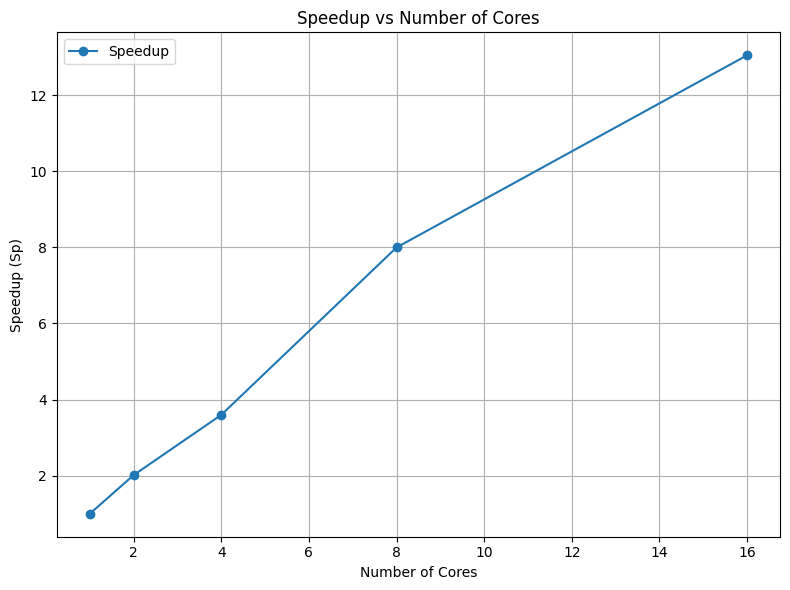

In [6]:
# Plot settings
plt.figure(figsize=(8, 6))
plt.plot(cores, Sp, marker='o', label='Speedup')
plt.xlabel('Number of Cores')
plt.ylabel('Speedup (Sp)')
plt.title('Speedup vs Number of Cores')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

- Compare your observed speedup to Amdahl's Law and discuss any discrepancies between the observed and theoretical speedup.

In [7]:
# Define T1 for Amdahl's Law
t_serial = time[0]
# Define the Amdahl's Law 
# We assume that the optimized is 95%
time_optimized = 0.95  
# Define the overall speedup
speedup_overall = 1 / ((1 - time_optimized) + (time_optimized / cores))
# Theorical time expected
t_theoretical = t_serial / speedup_overall

In [8]:
# Define ideal speedup
i_arr = np.full(cores.shape, t_serial)/cores

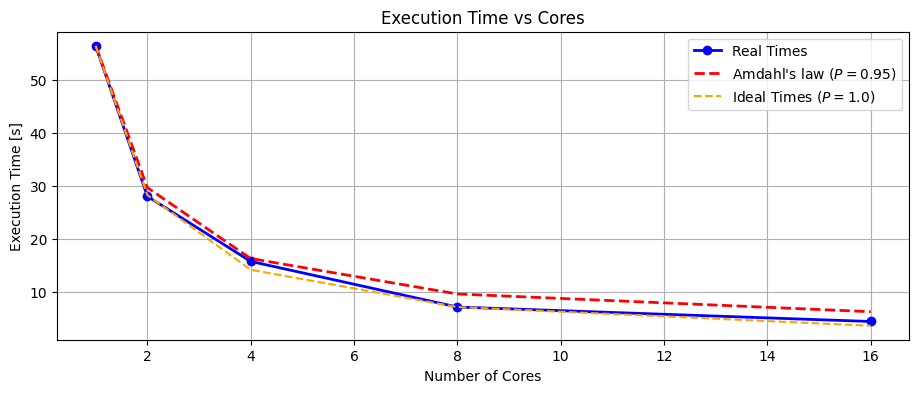

In [9]:
# Create the plot
plt.figure(figsize=(11, 4))
# Plot real time
plt.plot(cores, time,'o-', linewidth=2, label='Real Times', color='blue')
# Plot Amdahl's Law
plt.plot(cores, t_theoretical, '--', linewidth=2, label='Amdahl\'s law ($P=0.95$)', color='red')
# Ideal time
plt.plot(cores, i_arr, '--', color='orange', label='Ideal Times ($P=1.0$)')
# Settings of the plot
plt.xlabel('Number of Cores')
plt.ylabel('Execution Time [s]')
plt.title('Execution Time vs Cores')
plt.grid()
plt.legend()
plt.show()

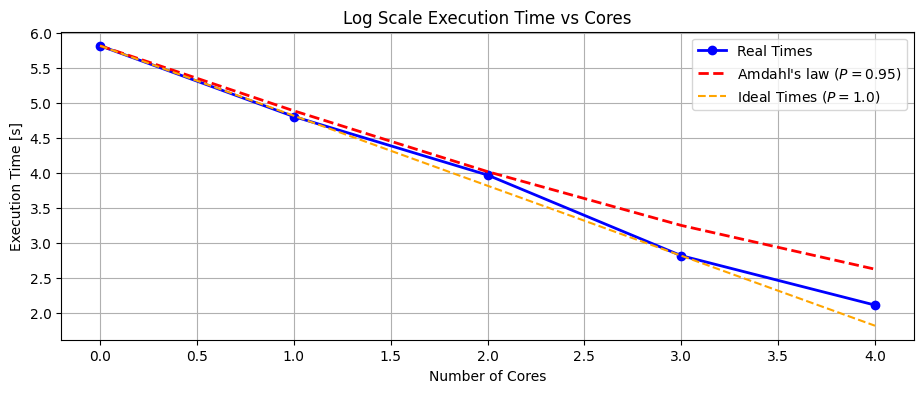

In [10]:
# Create the plot
plt.figure(figsize=(11, 4))
# Plot real time
plt.plot(np.log2(cores), np.log2(time),'o-', linewidth=2, label='Real Times', color='blue')
# Plot Amdahl's Law
plt.plot(np.log2(cores), np.log2(t_theoretical), '--', linewidth=2, label='Amdahl\'s law ($P=0.95$)', color='red')
# Ideal time
plt.plot(np.log2(cores), np.log2(i_arr), '--', color='orange', label='Ideal Times ($P=1.0$)')
# Settings of the plot
plt.xlabel('Number of Cores')
plt.ylabel('Execution Time [s]')
plt.title('Log Scale Execution Time vs Cores')
plt.grid()
plt.legend()
plt.show()

##### Looking at both plots and comparing them with Amdahl’s law, we can conclude that the results were significantly better, possibly because the MPI parallelization using the 16 cores achieved a balance where communication time was efficient, nearly matching in some points with the ideal time curve. However, in general, we can say that MPI parallelization reduced execution time, and in this case, data collection time had a minimal impact.